In [10]:
from google.colab import files

uploaded = files.upload()

Saving student_dropout_dataset_v3.csv to student_dropout_dataset_v3.csv


In [11]:
import pandas as pd

df = pd.read_csv("student_dropout_dataset_v3.csv")

df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [12]:
df.shape


(10000, 19)

In [13]:

df.columns

Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

In [14]:
df.dtypes

,0
Student_ID,int64
Age,float64
Gender,object
Family_Income,float64
Internet_Access,object
Study_Hours_per_Day,float64
Attendance_Rate,float64
Assignment_Delay_Days,int64
Travel_Time_Minutes,float64
Part_Time_Job,object


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [16]:
df["Dropout"].value_counts()

,count
Dropout,
0,7646
1,2354


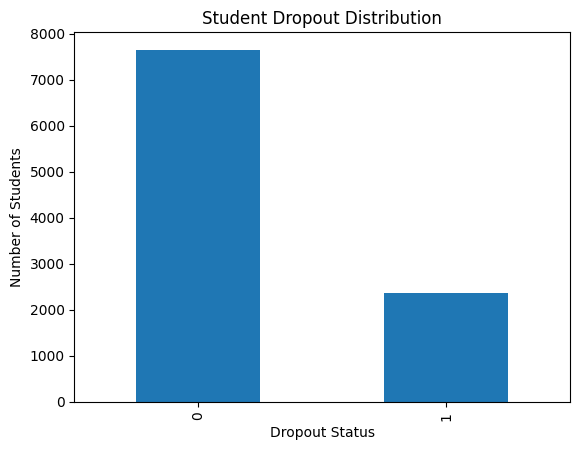

In [17]:
import matplotlib.pyplot as plt

df["Dropout"].value_counts().plot(kind="bar")

plt.title("Student Dropout Distribution")
plt.xlabel("Dropout Status")
plt.ylabel("Number of Students")
plt.show()

**Phase 3**

**Missing Value Analysis**

In [18]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Family_Income,500
Internet_Access,0
Study_Hours_per_Day,500
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


In [19]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Family_Income          500
Study_Hours_per_Day    500
Stress_Index           500
Parental_Education     511
dtype: int64


**Duplicate** **Records**

In [20]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


**Clean Categorical Text**

In [21]:
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip()

**Handle Missing Values**

*Numeric* *columns*

In [22]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

*Categorical columns*

In [23]:
categorical_columns = df.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [24]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Family_Income,0
Internet_Access,0
Study_Hours_per_Day,0
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


**Remove Student ID**

*Ater remove check*

In [25]:
print(df.columns.tolist())

['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department', 'Parental_Education', 'Dropout']


**Separate Features and Target**

In [26]:
X = df.drop(columns=["Dropout"])
y = df["Dropout"]

**Find Categorical Columns**

In [27]:
categorical_columns = X.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']


**Encode Categorical Variables**

In [28]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

*Check*

In [29]:
X_encoded.head()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,...,Semester_Year 2,Semester_Year 3,Semester_Year 4,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD
0,1,22.1,25000.0,3.36,86.1,2,20.4,5.5,0.96,0.90,...,False,False,False,False,False,False,False,True,False,False
1,2,20.7,25000.0,4.30,68.0,2,44.0,6.8,1.28,1.20,...,False,True,False,False,False,True,False,False,False,False
2,3,22.4,40183.0,4.40,70.9,0,48.9,5.5,1.68,1.32,...,False,False,False,False,False,False,False,False,True,False
3,4,24.4,29740.5,4.00,82.2,2,38.6,5.5,1.78,1.77,...,False,False,False,False,True,False,False,True,False,False
4,5,20.5,25319.0,4.19,75.7,1,23.0,7.0,1.48,0.91,...,False,False,True,True,False,False,False,False,False,False


**Everything Is Numeric**

In [30]:
print(X_encoded.dtypes)

Student_ID                          int64
Age                               float64
Family_Income                     float64
Study_Hours_per_Day               float64
Attendance_Rate                   float64
Assignment_Delay_Days               int64
Travel_Time_Minutes               float64
Stress_Index                      float64
GPA                               float64
Semester_GPA                      float64
CGPA                              float64
Gender_Male                          bool
Internet_Access_Yes                  bool
Part_Time_Job_Yes                    bool
Scholarship_Yes                      bool
Semester_Year 2                      bool
Semester_Year 3                      bool
Semester_Year 4                      bool
Department_Business                  bool
Department_CS                        bool
Department_Engineering               bool
Department_Science                   bool
Parental_Education_High School       bool
Parental_Education_Master         

In [31]:
print("Non-numeric columns:")
print(X_encoded.select_dtypes(exclude=["number"]).columns.tolist())

Non-numeric columns:
['Gender_Male', 'Internet_Access_Yes', 'Part_Time_Job_Yes', 'Scholarship_Yes', 'Semester_Year 2', 'Semester_Year 3', 'Semester_Year 4', 'Department_Business', 'Department_CS', 'Department_Engineering', 'Department_Science', 'Parental_Education_High School', 'Parental_Education_Master', 'Parental_Education_PhD']


**Check the Final Dataset**

In [32]:
print("Final feature shape:", X_encoded.shape)

Final feature shape: (10000, 25)


In [33]:
X_encoded.head()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,...,Semester_Year 2,Semester_Year 3,Semester_Year 4,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD
0,1,22.1,25000.0,3.36,86.1,2,20.4,5.5,0.96,0.90,...,False,False,False,False,False,False,False,True,False,False
1,2,20.7,25000.0,4.30,68.0,2,44.0,6.8,1.28,1.20,...,False,True,False,False,False,True,False,False,False,False
2,3,22.4,40183.0,4.40,70.9,0,48.9,5.5,1.68,1.32,...,False,False,False,False,False,False,False,False,True,False
3,4,24.4,29740.5,4.00,82.2,2,38.6,5.5,1.78,1.77,...,False,False,False,False,True,False,False,True,False,False
4,5,20.5,25319.0,4.19,75.7,1,23.0,7.0,1.48,0.91,...,False,False,True,True,False,False,False,False,False,False


In [34]:
y.head()

,Dropout
0,0
1,1
2,0
3,1
4,0


**Final Missing-Value Check**

In [35]:
print("Missing values:", X_encoded.isnull().sum().sum())

Missing values: 0


**Check Duplicate Rows**

In [36]:
print("Duplicate rows:", X_encoded.duplicated().sum())

Duplicate rows: 0


**Final Target Check**

In [37]:
print("Target distribution:")
print(y.value_counts())

Target distribution:
Dropout
0    7646
1    2354
Name: count, dtype: int64


**Dataset Preview**

In [38]:
print("Final dataset preview:")
display(X_encoded.head())

Final dataset preview:


,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,...,Semester_Year 2,Semester_Year 3,Semester_Year 4,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD
0,1,22.1,25000.0,3.36,86.1,2,20.4,5.5,0.96,0.90,...,False,False,False,False,False,False,False,True,False,False
1,2,20.7,25000.0,4.30,68.0,2,44.0,6.8,1.28,1.20,...,False,True,False,False,False,True,False,False,False,False
2,3,22.4,40183.0,4.40,70.9,0,48.9,5.5,1.68,1.32,...,False,False,False,False,False,False,False,False,True,False
3,4,24.4,29740.5,4.00,82.2,2,38.6,5.5,1.78,1.77,...,False,False,False,False,True,False,False,True,False,False
4,5,20.5,25319.0,4.19,75.7,1,23.0,7.0,1.48,0.91,...,False,False,True,True,False,False,False,False,False,False


# **Phase 4**

In [39]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 19)


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,29740.5,Yes,4.00,82.2,2,38.6,No,No,5.5,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


**Check Dropout Distribution**

In [40]:
import matplotlib.pyplot as plt

print(df["Dropout"].value_counts())

Dropout
0    7646
1    2354
Name: count, dtype: int64


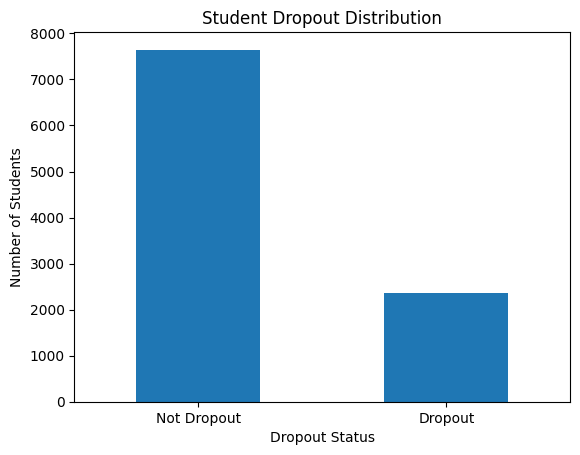

In [41]:
df["Dropout"].value_counts().plot(kind="bar")

plt.title("Student Dropout Distribution")
plt.xlabel("Dropout Status")
plt.ylabel("Number of Students")
plt.xticks([0, 1], ["Not Dropout", "Dropout"], rotation=0)
plt.show()

**Academic Performance**

***GPA***

In [42]:
print(df.groupby("Dropout")["GPA"].mean())

Dropout
0    2.579623
1    1.427613
Name: GPA, dtype: float64


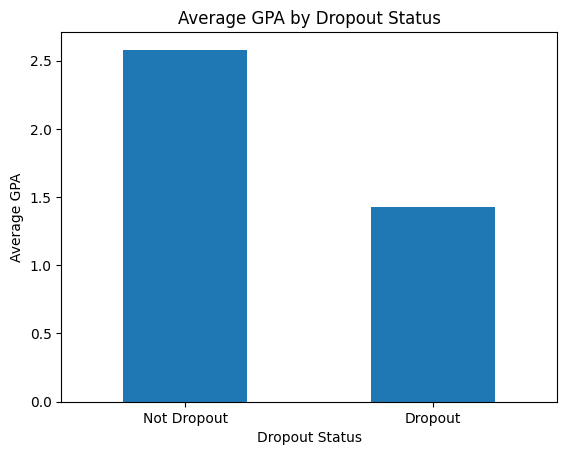

In [43]:
df.groupby("Dropout")["GPA"].mean().plot(kind="bar")

plt.title("Average GPA by Dropout Status")
plt.xlabel("Dropout Status")
plt.ylabel("Average GPA")
plt.xticks([0, 1], ["Not Dropout", "Dropout"], rotation=0)
plt.show()

***Attendance***

In [44]:
print(df.groupby("Dropout")["Attendance_Rate"].mean())

Dropout
0    82.482775
1    79.313934
Name: Attendance_Rate, dtype: float64


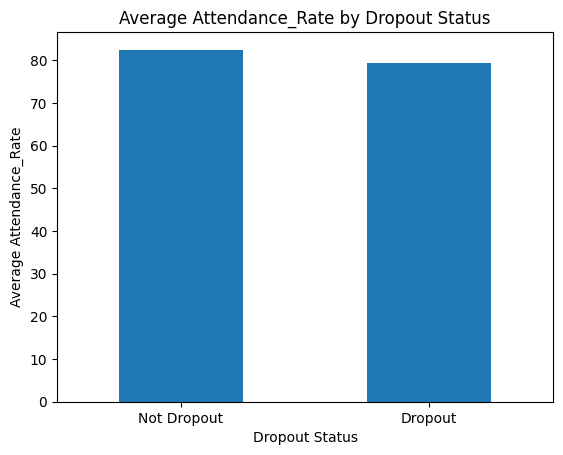

In [45]:
df.groupby("Dropout")["Attendance_Rate"].mean().plot(kind="bar")

plt.title("Average Attendance_Rate by Dropout Status")
plt.xlabel("Dropout Status")
plt.ylabel("Average Attendance_Rate")
plt.xticks([0, 1], ["Not Dropout", "Dropout"], rotation=0)
plt.show()

***Study_Hours_per_Day***

In [46]:
print(df.groupby("Dropout")["Study_Hours_per_Day"].mean())

Dropout
0    4.074925
1    3.815523
Name: Study_Hours_per_Day, dtype: float64


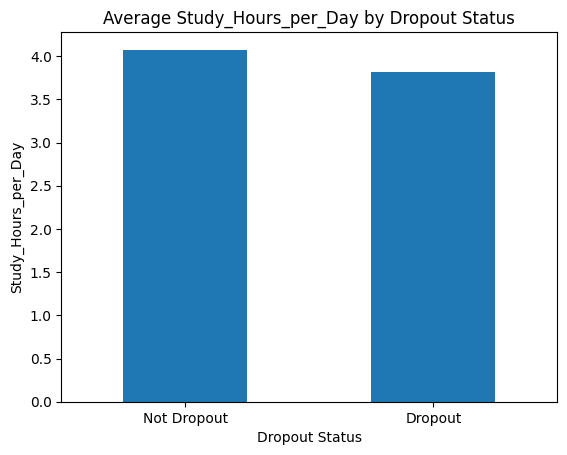

In [47]:
df.groupby("Dropout")["Study_Hours_per_Day"].mean().plot(kind="bar")

plt.title("Average Study_Hours_per_Day by Dropout Status")
plt.xlabel("Dropout Status")
plt.ylabel("Study_Hours_per_Day")
plt.xticks([0, 1], ["Not Dropout", "Dropout"], rotation=0)
plt.show()

**Additional risk factor**

***Stress Index***

In [48]:
print(df.groupby("Dropout")["Stress_Index"].mean())

Dropout
0    5.268650
1    6.280289
Name: Stress_Index, dtype: float64


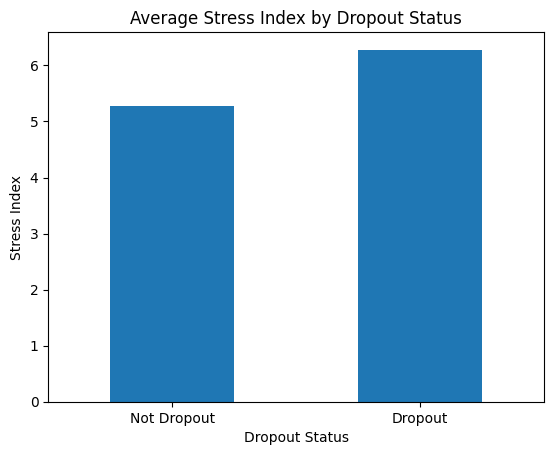

In [49]:
df.groupby("Dropout")["Stress_Index"].mean().plot(kind="bar")

plt.title("Average Stress Index by Dropout Status")
plt.xlabel("Dropout Status")
plt.ylabel("Stress Index")
plt.xticks([0, 1], ["Not Dropout", "Dropout"], rotation=0)
plt.show()

**Demographic relationship**

**examine a categorical feature [Gender vs Dropout]**

In [50]:
gender_dropout = pd.crosstab(df["Gender"], df["Dropout"])

print(gender_dropout)

Dropout     0     1
Gender             
Female   3816  1195
Male     3830  1159


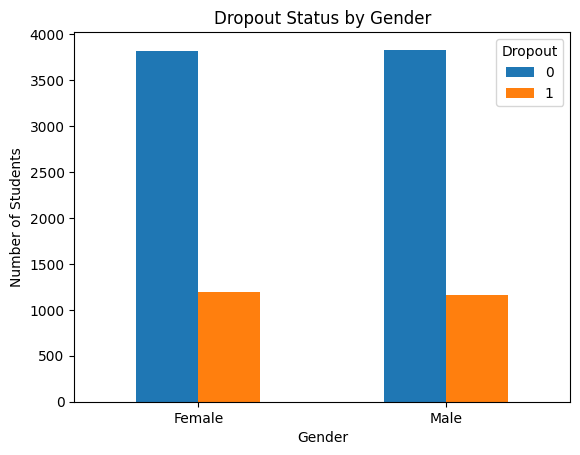

In [51]:
gender_dropout.plot(kind="bar")

plt.title("Dropout Status by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

**Statistical analysis**

**Correlation with Dropout**

***Numerical Feature Relationships***

In [52]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

print(correlation["Dropout"].sort_values())

GPA                     -0.460352
Semester_GPA            -0.445396
CGPA                    -0.444807
Attendance_Rate         -0.163539
Study_Hours_per_Day     -0.087163
Family_Income           -0.010324
Student_ID               0.007434
Age                      0.007585
Travel_Time_Minutes      0.028080
Assignment_Delay_Days    0.082327
Stress_Index             0.249361
Dropout                  1.000000
Name: Dropout, dtype: float64


***Create Feature Relationship Chart***

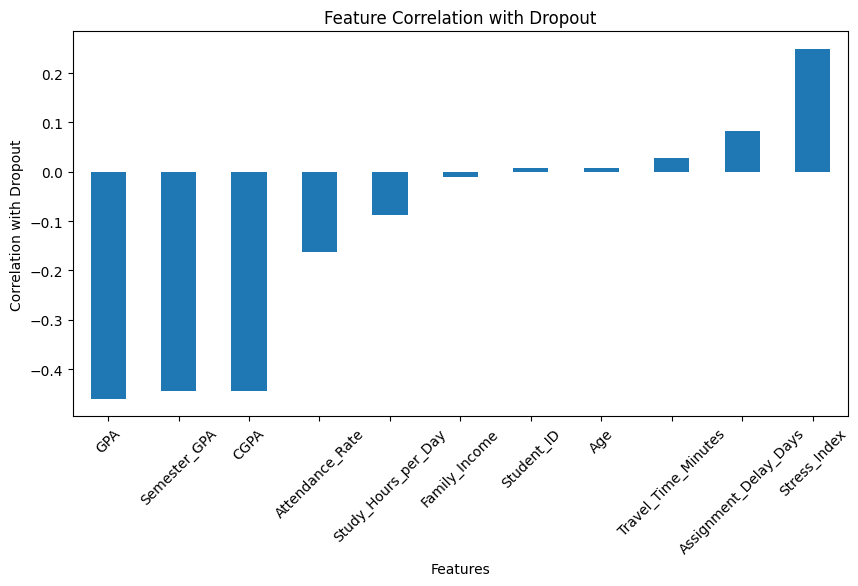

In [53]:
dropout_corr = correlation["Dropout"].drop("Dropout")

dropout_corr.sort_values().plot(kind="bar", figsize=(10, 5))

plt.title("Feature Correlation with Dropout")
plt.xlabel("Features")
plt.ylabel("Correlation with Dropout")
plt.xticks(rotation=45)
plt.show()

**Create a Simple Academic Summary**

In [54]:
academic_summary = df.groupby("Dropout")[[
    "GPA",
    "Attendance_Rate",
    "Study_Hours_per_Day",
    "Stress_Index"
]].mean()

academic_summary

,GPA,Attendance_Rate,Study_Hours_per_Day,Stress_Index
Dropout,,,,
0,2.579623,82.482775,4.074925,5.268650
1,1.427613,79.313934,3.815523,6.280289


**GPA Distribution by Dropout Status**

<Figure size 700x500 with 0 Axes>

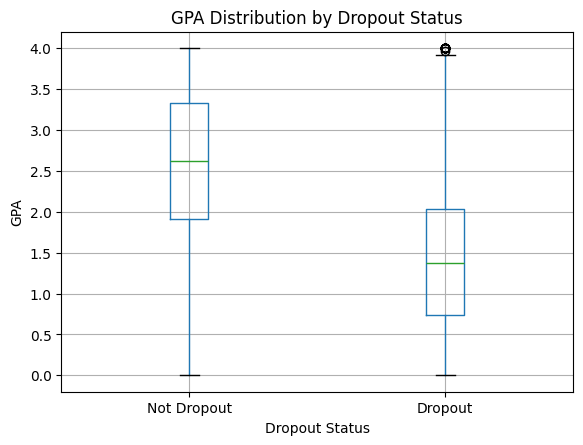

In [55]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="GPA",
    by="Dropout"
)

plt.title("GPA Distribution by Dropout Status")
plt.suptitle("")
plt.xlabel("Dropout Status")
plt.ylabel("GPA")
plt.xticks([1, 2], ["Not Dropout", "Dropout"])

plt.show()

# **Phase 5**

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

**Check target values**

In [57]:
print("Dropout Class Distribution:")
print(df["Dropout"].value_counts())

Dropout Class Distribution:
Dropout
0    7646
1    2354
Name: count, dtype: int64


**Separate features and target**

In [58]:
X = df.drop("Dropout", axis=1)
y = df["Dropout"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 18)
Target shape: (10000,)


In [59]:
print(df.columns.tolist())


['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department', 'Parental_Education', 'Dropout']


**Split the dataset**

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (8000, 18)
Testing data: (2000, 18)
Training target: (8000,)
Testing target: (2000,)


**numerical and categorical features**

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['Student_ID', 'Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']

Categorical features:
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']


**Create preprocessing**

In [62]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Create the Logistic Regression model**

In [63]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

**Train the model**

In [64]:
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


**Make predictions**

In [65]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 0 0 ... 0 0 0]


**Generate prediction probabilities**

In [66]:
y_prob = model.predict_proba(X_test)

print("Prediction Probabilities:")
print(y_prob)

Prediction Probabilities:
[[0.89645056 0.10354944]
 [0.77211361 0.22788639]
 [0.91572127 0.08427873]
 ...
 [0.91778504 0.08221496]
 [0.68169513 0.31830487]
 [0.54344624 0.45655376]]


**Check which probability column is Dropout**

In [67]:
print("Class order:")
print(model.classes_)

Class order:
[0 1]


**Display Dropout probability**

In [68]:
dropout_probability = y_prob[:, 1]

print("Dropout Probabilities:")
print(dropout_probability)

Dropout Probabilities:
[0.10354944 0.22788639 0.08427873 ... 0.08221496 0.31830487 0.45655376]


**Calculate accuracy**

In [69]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8145


**Generate classification report**

In [70]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1529
           1       0.68      0.40      0.50       471

    accuracy                           0.81      2000
   macro avg       0.76      0.67      0.70      2000
weighted avg       0.80      0.81      0.80      2000



**Create a clean prediction table**

In [71]:
results = X_test.copy()

results["Actual"] = y_test.values
results["Predicted"] = y_pred

print(results.head(10))

      Student_ID   Age  Gender  Family_Income Internet_Access  \
7574        7575  19.4  Female       110124.0             Yes   
3523        3524  24.6    Male        82238.0             Yes   
7890        7891  21.4    Male        25000.0              No   
6115        6116  18.7  Female        32565.0             Yes   
8319        8320  19.9  Female        25000.0             Yes   
117          118  18.4  Female        30045.0              No   
3484        3485  18.8  Female        26618.0             Yes   
9214        9215  19.6  Female        34913.0             Yes   
6072        6073  21.4    Male        25000.0             Yes   
9767        9768  21.1  Female        49936.0             Yes   

      Study_Hours_per_Day  Attendance_Rate  Assignment_Delay_Days  \
7574                 6.57             80.4                      2   
3523                 3.20             79.4                      1   
7890                 2.40             79.5                      2   
6115    

# **Phase 6**

**Import evaluation metrics**

In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

**Make predictions on testing data**

In [73]:
# Predict class labels
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 0 0 ... 0 0 0]


**Get prediction probabilities**

In [74]:
# Predict probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Prediction Probabilities:")
print(y_pred_proba)

Prediction Probabilities:
[0.10354944 0.22788639 0.08427873 ... 0.08221496 0.31830487 0.45655376]


**Calculate Accuracy**

In [75]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8145


**Calculate Precision**

In [76]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.6798561151079137


**Calculate Recall**

In [77]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.4012738853503185


**Calculate Recall**

In [78]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.4012738853503185


**Calculate F1-score**

In [79]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.5046728971962616


**Display all metrics together**

In [80]:
print("Model Evaluation Metrics")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Model Evaluation Metrics
Accuracy : 0.8145
Precision: 0.6798561151079137
Recall   : 0.4012738853503185
F1 Score : 0.5046728971962616


**Create the Confusion Matrix**

In [81]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1440   89]
 [ 282  189]]


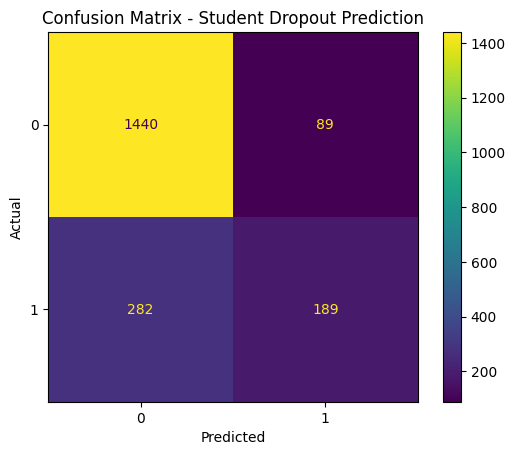

In [82]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - Student Dropout Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Classification Report**

In [83]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1529
           1       0.68      0.40      0.50       471

    accuracy                           0.81      2000
   macro avg       0.76      0.67      0.70      2000
weighted avg       0.80      0.81      0.80      2000



**Calculate ROC-AUC**

In [84]:
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.820702094954031


**Put all required metrics in one final cell**

In [85]:
print("Final Model Evaluation")
print("======================")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Final Model Evaluation
Accuracy : 0.8145
Precision: 0.6798561151079137
Recall   : 0.4012738853503185
F1 Score : 0.5046728971962616
ROC-AUC  : 0.820702094954031

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1529
           1       0.68      0.40      0.50       471

    accuracy                           0.81      2000
   macro avg       0.76      0.67      0.70      2000
weighted avg       0.80      0.81      0.80      2000

Confusion Matrix:
[[1440   89]
 [ 282  189]]


**Analyze False Positives and False Negatives**

In [86]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("False Positives:", fp)
print("False Negatives:", fn)

False Positives: 89
False Negatives: 282


**Phase 7**

**Student Dropout Risk Prediction Application**

In [139]:
import pandas as pd
import numpy as np
import gradio as gr

**Check that the Phase 5 model exists**


In [140]:

print("Trained model:", model)
print("\nModel classes:", model.classes_)
print("\nFeatures used by model:")
print(list(X.columns))

Trained model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Student_ID', 'Age', 'Family_Income', 'Study_Hours_per_Day',
       'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes',
       'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                   

**STUDENT RISK PREDICTION**

In [141]:

def predict_student(student_data):

    # Convert input into DataFrame
    student_df = pd.DataFrame([student_data])

    # Make prediction
    prediction = model.predict(student_df)[0]

    # Get probability
    probabilities = model.predict_proba(student_df)[0]

    # Get class order
    classes = list(model.classes_)

    # Find probability of dropout
    if 1 in classes:
        dropout_probability = probabilities[classes.index(1)]

    elif "Yes" in classes:
        dropout_probability = probabilities[classes.index("Yes")]

    elif "Dropout" in classes:
        dropout_probability = probabilities[classes.index("Dropout")]

    else:
        dropout_probability = probabilities[-1]

    # Convert prediction to readable text
    if prediction == 1:
        prediction_text = "Dropout"
    elif prediction == 0:
        prediction_text = "No Dropout"
    else:
        prediction_text = str(prediction)

    # Risk category
    if dropout_probability < 0.30:
        risk_category = "Low Risk"

    elif dropout_probability < 0.60:
        risk_category = "Medium Risk"

    else:
        risk_category = "High Risk"

    return prediction_text, dropout_probability, risk_category

**TEST ONE STUDENT**

In [142]:
student = X_test.iloc[0].to_dict()

prediction, probability, risk = predict_student(student)

print("Student Prediction")
print("----------------------------")
print("Prediction:", prediction)
print("Dropout Probability:", f"{probability * 100:.2f}%")
print("Risk Category:", risk)

Student Prediction
----------------------------
Prediction: No Dropout
Dropout Probability: 10.35%
Risk Category: Low Risk


**MULTIPLE TEST CASES**

In [143]:
test_results = []

for i in range(min(5, len(X_test))):

    student = X_test.iloc[i].to_dict()

    prediction, probability, risk = predict_student(student)

    test_results.append({
        "Student": f"Student {i + 1}",
        "Actual": y_test.iloc[i],
        "Predicted": prediction,
        "Dropout Probability": f"{probability * 100:.2f}%",
        "Risk Category": risk
    })

results_df = pd.DataFrame(test_results)

results_df

,Student,Actual,Predicted,Dropout Probability,Risk Category
0,Student 1,0,No Dropout,10.35%,Low Risk
1,Student 2,0,No Dropout,22.79%,Low Risk
2,Student 3,0,No Dropout,8.43%,Low Risk
3,Student 4,0,No Dropout,27.25%,Low Risk
4,Student 5,1,No Dropout,46.23%,Medium Risk


**APPLICATION PREDICTION FUNCTION**

In [144]:

def application_prediction(*values):

    try:

        # Create student dictionary
        student_data = {}

        for column, value in zip(X.columns, values):
            student_data[column] = value

        # Check missing values
        for column, value in student_data.items():

            if value is None or value == "":
                return (
                    "Please complete all fields.",
                    "—",
                    "—",
                    "Please enter all student information."
                )

        # Predict
        prediction, probability, risk = predict_student(student_data)

        # Percentage
        probability_percentage = probability * 100

        # Interpretation
        if risk == "Low Risk":

            message = (
                "The model predicts a relatively low probability "
                "of student dropout."
            )

        elif risk == "Medium Risk":

            message = (
                "The model predicts a moderate probability "
                "of student dropout."
            )

        else:

            message = (
                "The model predicts a higher probability "
                "of student dropout."
            )

        return (
            prediction,
            f"{probability_percentage:.2f}%",
            risk,
            message
        )

    except Exception as e:

        return (
            "Prediction Error",
            "—",
            "—",
            f"Error: {str(e)}"
        )

In [148]:
import gradio as gr

# ---------- Custom CSS ----------
custom_css = """
body {
    background: #f5f7fb;
}

.gradio-container {
    max-width: 1150px !important;
    margin: auto !important;
}

/* Header */
.header {
    text-align: center;
    padding: 30px 10px 25px;
}

.header h1 {
    font-size: 34px;
    margin-bottom: 6px;
    font-weight: 800;
}

.header p {
    font-size: 15px;
    opacity: 0.65;
}

/* Cards */
.card {
    border-radius: 20px !important;
    padding: 25px !important;
    border: 1px solid #e3e7ef !important;
    box-shadow: 0 6px 20px rgba(0,0,0,0.05);
    background: white !important;
}

/* Section headings */
.section-title {
    font-size: 21px;
    font-weight: 750;
    margin-bottom: 4px;
}

.section-subtitle {
    font-size: 13px;
    opacity: 0.6;
    margin-bottom: 20px;
}

/* Inputs */
input, textarea, select {
    border-radius: 10px !important;
}

/* Button */
.predict-btn {
    margin-top: 18px;
    border-radius: 12px !important;
    font-size: 16px !important;
    font-weight: 700 !important;
}

/* Result cards */
.result-card {
    text-align: center;
    padding: 20px;
    border-radius: 16px;
    margin-bottom: 15px;
    border: 1px solid #e5e7eb;
}

.result-title {
    font-size: 13px;
    text-transform: uppercase;
    letter-spacing: 1px;
    opacity: 0.6;
}

.result-value {
    font-size: 30px;
    font-weight: 800;
    margin-top: 7px;
}

/* Probability */
.probability {
    font-size: 45px;
    font-weight: 850;
    margin-top: 5px;
}

/* Footer */
.footer {
    text-align: center;
    padding: 25px;
    font-size: 12px;
    opacity: 0.5;
}
"""

# ---------- Interface ----------
with gr.Blocks(
    title="Student Dropout Prediction",
    css=custom_css,
    theme=gr.themes.Soft(
        primary_hue="indigo",
        secondary_hue="slate"
    )
) as demo:

    # Header
    gr.HTML("""
    <div class="header">
        <h1>🎓 Student Dropout Prediction</h1>
        <p>Student Risk Assessment using Machine Learning</p>
    </div>
    """)

    with gr.Row():

        # ================= INPUT SECTION =================
        with gr.Column(
            scale=1,
            elem_classes="card"
        ):

            gr.HTML("""
            <div class="section-title">👤 Student Information</div>
            <div class="section-subtitle">
                Enter the student's details to assess dropout risk.
            </div>
            """)

            interface_inputs = []

            # Create inputs automatically from dataset
            for column in X.columns:

                if column in numeric_features:

                    component = gr.Number(
                        label=column,
                        value=float(df[column].median())
                    )

                else:

                    choices = (
                        df[column]
                        .dropna()
                        .unique()
                        .tolist()
                    )

                    component = gr.Dropdown(
                        choices=choices,
                        label=column,
                        value=choices[0] if choices else None
                    )

                interface_inputs.append(component)

            predict_button = gr.Button(
                "🔍 Predict Dropout Risk",
                variant="primary",
                size="lg",
                elem_classes="predict-btn"
            )

            clear_button = gr.ClearButton(
                components=interface_inputs,
                value="Clear Form"
            )

        # ================= RESULT SECTION =================
        with gr.Column(
            scale=1,
            elem_classes="card"
        ):

            gr.HTML("""
            <div class="section-title">📊 Risk Assessment</div>
            <div class="section-subtitle">
                Prediction generated by the trained Logistic Regression model.
            </div>
            """)

            prediction_result = gr.HTML(
                """
                <div class="result-card">
                    <div class="result-title">Prediction</div>
                    <div class="result-value">Waiting...</div>
                </div>
                """
            )

            probability_result = gr.HTML(
                """
                <div class="result-card">
                    <div class="result-title">Dropout Probability</div>
                    <div class="probability">--</div>
                </div>
                """
            )

            risk_result = gr.HTML(
                """
                <div class="result-card">
                    <div class="result-title">Risk Category</div>
                    <div class="result-value">--</div>
                </div>
                """
            )

            message_result = gr.HTML(
                """
                <div class="result-card">
                    <div class="result-title">Assessment</div>
                    <div style="margin-top:10px; opacity:0.7;">
                        Enter student information and click
                        <b>Predict Dropout Risk</b>.
                    </div>
                </div>
                """
            )

    gr.HTML("""
    <div class="footer">
        Student Dropout Prediction • Machine Learning Project
    </div>
    """)

    # ---------- Prediction connection ----------
    def styled_prediction(*values):

        prediction, probability, risk, message = application_prediction(*values)

        # Prediction styling
        prediction_html = f"""
        <div class="result-card">
            <div class="result-title">Prediction</div>
            <div class="result-value">{prediction}</div>
        </div>
        """

        # Probability styling
        probability_html = f"""
        <div class="result-card">
            <div class="result-title">Dropout Probability</div>
            <div class="probability">{probability}</div>
        </div>
        """

        # Risk styling
        if risk == "Low Risk":
            icon = "🟢"
        elif risk == "Medium Risk":
            icon = "🟡"
        else:
            icon = "🔴"

        risk_html = f"""
        <div class="result-card">
            <div class="result-title">Risk Category</div>
            <div class="result-value">{icon} {risk}</div>
        </div>
        """

        # Assessment styling
        message_html = f"""
        <div class="result-card">
            <div class="result-title">Assessment</div>
            <div style="margin-top:10px; font-size:15px;">
                {message}
            </div>
        </div>
        """

        return (
            prediction_html,
            probability_html,
            risk_html,
            message_html
        )

    predict_button.click(
        fn=styled_prediction,
        inputs=interface_inputs,
        outputs=[
            prediction_result,
            probability_result,
            risk_result,
            message_result
        ]
    )

demo.launch()

/tmp/ipykernel_1145/2218753341.py:105: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5401b03bfa86aeabb1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**CREATE INPUT FIELDS**

In [145]:


input_components = []

for column in X.columns:

    # Numerical features
    if column in numeric_features:

        default_value = df[column].median()

        component = gr.Number(
            label=column,
            value=float(default_value)
        )

    # Categorical features
    else:

        choices = df[column].dropna().unique().tolist()

        component = gr.Dropdown(
            choices=choices,
            label=column,
            value=choices[0] if len(choices) > 0 else None
        )

    input_components.append(component)